# Tahap 1: Memuat dan Mengeksplorasi Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
import joblib

print("Semua library berhasil di-import.")

# 1. Muat Dataset
# Ganti 'Heart_disease_cleveland_new.csv' jika nama file Anda berbeda
file_path = 'Heart_disease_cleveland_new.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Dataset '{file_path}' berhasil dimuat.")
except FileNotFoundError:
    print(f"ERROR: File '{file_path}' tidak ditemukan. Pastikan file-nya ada di folder yang sama dengan notebook ini.")

# 2. Tampilkan 5 baris pertama untuk melihat data
print("\n--- 5 Baris Data Pertama ---")
print(df.head())

# 3. Tampilkan informasi kolom dan tipe data
print("\n--- Info Dataset ---")
df.info()

# 4. Cek data yang hilang (missing values)
print("\n--- Data Hilang (Missing Values) ---")
print(df.isnull().sum())

Semua library berhasil di-import.
Dataset 'Heart_disease_cleveland_new.csv' berhasil dimuat.

--- 5 Baris Data Pertama ---
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   0       145   233    1        2      150      0      2.3      2   
1   67    1   3       160   286    0        2      108      1      1.5      1   
2   67    1   3       120   229    0        2      129      1      2.6      1   
3   37    1   2       130   250    0        0      187      0      3.5      2   
4   41    0   1       130   204    0        2      172      0      1.4      0   

   ca  thal  target  
0   0     2       0  
1   3     1       1  
2   2     3       1  
3   0     1       0  
4   0     1       0  

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex      

# Tahap 2: Preprocessing & Persiapan Data

In [2]:
# 5. Pisahkan Fitur (X) dan Target (y)
# ==========================================================
# 'target' adalah apa yang ingin kita prediksi
y = df['target']
# 'X' adalah semua kolom LAINNYA yang kita gunakan untuk memprediksi
X = df.drop('target', axis=1)

print(f"Bentuk X (fitur) awal: {X.shape}")
print(f"Bentuk y (target) awal: {y.shape}")

# 6. One-Hot Encoding untuk Fitur Kategorikal
# ==========================================================
# Kita ubah kolom kategori (cp, restecg, dll.) menjadi kolom dummy
# Misal, 'cp' akan menjadi 'cp_0', 'cp_1', 'cp_2', 'cp_3'
# Ini mencegah model berpikir bahwa 'cp=3' > 'cp=1'
categorical_cols = ['cp', 'restecg', 'slope', 'ca', 'thal']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"\nBentuk X setelah One-Hot Encoding: {X_encoded.shape}")
print("Contoh 5 baris pertama data X yang sudah di-encode:")
print(X_encoded.head())

# 7. Bagi Data menjadi Training dan Testing
# ==========================================================
# Kita latih model pada 80% data, dan uji pada 20% data
# 'random_state=42' memastikan kita mendapat hasil yang sama setiap kali
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y # 'stratify=y' penting untuk data medis agar proporsi 0 & 1 sama
)

# 8. Penskalaan Fitur (Feature Scaling)
# ==========================================================
# Kita hanya menskalakan kolom numerik asli
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Buat scaler
scaler = StandardScaler()

# PENTING: Kita 'fit' (belajar) HANYA pada data training
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Kita 'transform' (menerapkan) data testing dengan skala yang sama
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("\nData training dan testing berhasil dibuat dan diskalakan.")
print("Contoh 5 baris pertama X_train yang sudah diskalakan:")
print(X_train.head())

# Simpan scaler ke file, kita akan butuh ini di app.py
# joblib.dump(scaler, 'heart_scaler.pkl') 
# Kita akan lakukan ini di cell terakhir setelah model jadi

Bentuk X (fitur) awal: (303, 13)
Bentuk y (target) awal: (303,)

Bentuk X setelah One-Hot Encoding: (303, 20)
Contoh 5 baris pertama data X yang sudah di-encode:
   age  sex  trestbps  chol  fbs  thalach  exang  oldpeak   cp_1   cp_2  \
0   63    1       145   233    1      150      0      2.3  False  False   
1   67    1       160   286    0      108      1      1.5  False  False   
2   67    1       120   229    0      129      1      2.6  False  False   
3   37    1       130   250    0      187      0      3.5  False   True   
4   41    0       130   204    0      172      0      1.4   True  False   

    cp_3  restecg_1  restecg_2  slope_1  slope_2   ca_1   ca_2   ca_3  thal_2  \
0  False      False       True    False     True  False  False  False    True   
1   True      False       True     True    False  False  False   True   False   
2   True      False       True     True    False  False   True  False   False   
3  False      False      False    False     True  False  False 

# Tahap 3: Melatih Model & Evaluasi Awal

In [3]:
# 9. Inisialisasi dan Latih Model (Logistic Regression)
# ==========================================================
print("Memulai pelatihan model Logistic Regression...")

# Kita inisialisasi modelnya
# 'random_state=42' agar hasilnya konsisten setiap kali dijalankan
# 'max_iter=1000' untuk memastikan modelnya punya cukup waktu belajar
model = LogisticRegression(random_state=42, max_iter=1000)

# Latih model HANYA pada data training
model.fit(X_train, y_train)

print("Model berhasil dilatih.")

# 10. Buat Prediksi pada Data Testing
# ==========================================================
# Sekarang kita uji seberapa baik modelnya pada data yang 'belum pernah dilihat'
y_pred = model.predict(X_test)

# 11. Evaluasi Performa Model
# ==========================================================
# Bandingkan prediksi model (y_pred) dengan jawaban sebenarnya (y_test)

# a. Hitung Akurasi
acc = accuracy_score(y_test, y_pred)
print(f"\n--- Hasil Evaluasi Model ---")
print(f"Akurasi Model: {acc * 100:.2f}%")

# b. Tampilkan Laporan Klasifikasi
# Ini akan menunjukkan 'precision', 'recall', dan 'f1-score'
# 0 = 'Normal'
# 1 = 'Sakit Jantung'
print("\n--- Laporan Klasifikasi ---")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Sakit Jantung (1)']))

Memulai pelatihan model Logistic Regression...
Model berhasil dilatih.

--- Hasil Evaluasi Model ---
Akurasi Model: 86.89%

--- Laporan Klasifikasi ---
                   precision    recall  f1-score   support

       Normal (0)       0.90      0.85      0.88        33
Sakit Jantung (1)       0.83      0.89      0.86        28

         accuracy                           0.87        61
        macro avg       0.87      0.87      0.87        61
     weighted avg       0.87      0.87      0.87        61



# Tahap 4: Membuat Grafik ROC Curve

Membuat grafik ROC Curve...
Nilai AUC: 0.9621


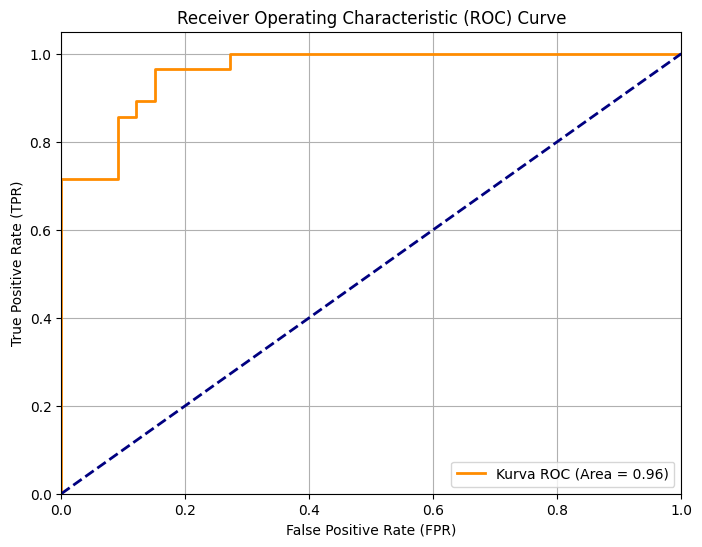

In [4]:
# 12. Membuat dan Menampilkan ROC Curve
# ==========================================================
print("Membuat grafik ROC Curve...")

# Pertama, kita perlu mendapatkan 'probabilitas' prediksi, bukan hanya 0 atau 1
# 'model.predict_proba(X_test)' mengembalikan 2 probabilitas [prob(0), prob(1)]
# Kita hanya perlu probabilitas untuk kelas '1' (Sakit Jantung)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Hitung FPR (False Positive Rate) dan TPR (True Positive Rate)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Hitung AUC (Area Under the Curve)
roc_auc = auc(fpr, tpr)
print(f"Nilai AUC: {roc_auc:.4f}")

# 13. Plotting Grafik
# ==========================================================
plt.figure(figsize=(8, 6))
# Plot kurva ROC
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'Kurva ROC (Area = {roc_auc:.2f})')
# Plot garis tebakan acak (baseline)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Tahap 5: Menyimpan Model, Scaler, dan Kolom

In [5]:
import joblib
import json

# 14. Menyimpan Model dan Scaler
# ==========================================================
# Kita gunakan 'joblib' karena lebih efisien untuk model sklearn
#
# a. Simpan Model
model_filename = 'heart_model.pkl'
joblib.dump(model, model_filename)
print(f"Model berhasil disimpan ke: {model_filename}")

# b. Simpan Scaler
scaler_filename = 'heart_scaler.pkl'
joblib.dump(scaler, scaler_filename)
print(f"Scaler berhasil disimpan ke: {scaler_filename}")

# c. Simpan Daftar Kolom
# Kita perlu ini agar app.py tahu urutan kolom yang benar
# 'list(X_encoded.columns)' mengambil semua nama kolom (termasuk dummy)
column_list = list(X_encoded.columns)
columns_filename = 'heart_columns.json'

with open(columns_filename, 'w') as f:
    json.dump(column_list, f)
print(f"Daftar kolom berhasil disimpan ke: {columns_filename}")

print("\n--- Training Selesai! ---")
print("File yang dihasilkan (siap untuk app.py):")
print(f"1. {model_filename} (Model AI Anda)")
print(f"2. {scaler_filename} (Preprocessor Anda)")
print(f"3. {columns_filename} (Struktur data Anda)")

Model berhasil disimpan ke: heart_model.pkl
Scaler berhasil disimpan ke: heart_scaler.pkl
Daftar kolom berhasil disimpan ke: heart_columns.json

--- Training Selesai! ---
File yang dihasilkan (siap untuk app.py):
1. heart_model.pkl (Model AI Anda)
2. heart_scaler.pkl (Preprocessor Anda)
3. heart_columns.json (Struktur data Anda)
